In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.special import sici, erf
from pyccl.halos import HaloProfile
import pyccl as ccl
import numpy as np

In [2]:
class HaloProfileHOD_DES(HaloProfile):
    __repr_attrs__ = __eq_attrs__ = (
        "log10Mmin_0", "log10Mmin_p", "siglogM_0", "siglogM_p", "log10M0_0",
        "log10M0_p", "log10M1_0", "log10M1_p", "alpha_0", "alpha_p", "fc_0",
        "fc_p", "bg_0", "bg_p", "bmax_0", "bmax_p", "aratio_0", "aratio_p", "a_pivot",
        "_is_number_counts", "mass_def", "concentration",
        "precision_fftlog",)

    def __init__(self, *, mass_def, concentration,
                 log10Mmin_0=12., log10Mmin_p=0., 
                 siglogM_0=0.4, siglogM_p=0.,
                 log10M1_0=13.3, log10M1_p=0., alpha_0=1.,
                 alpha_p=0., fc_0=1., fc_p=0.,
                 aratio_0=1., aratio_p=0.,
                 a_pivot=1.,
                 is_number_counts=True,
                 cen_on=True, sat_on=True):
        self.log10Mmin_0 = log10Mmin_0
        self.log10Mmin_p = log10Mmin_p
        self.log10M1_0 = log10M1_0
        self.log10M1_p = log10M1_p
        self.siglogM_0 = siglogM_0
        self.siglogM_p = siglogM_p
        self.alpha_0 = alpha_0
        self.alpha_p = alpha_p
        self.fc_0 = fc_0
        self.fc_p = fc_p
        self.aratio_0 = aratio_0
        self.aratio_p = aratio_p
        self.a_pivot = a_pivot
        self.cen_on = cen_on
        self.sat_on = sat_on
        super().__init__(mass_def=mass_def, concentration=concentration,
                         is_number_counts=is_number_counts)

    def update_parameters(self, *, log10Mmin_0=None, log10Mmin_p=None,
                          siglogM_0=None, siglogM_p=None,
                          log10M1_0=None, log10M1_p=None,
                          alpha_0=None, alpha_p=None,
                          fc_0=None, fc_p=None,
                          aratio_0=None, aratio_p=None,
                          a_pivot=None,
                          cen_on=None, sat_on=None,):
        if log10Mmin_0 is not None:
            self.log10Mmin_0 = log10Mmin_0
        if log10Mmin_p is not None:
            self.log10Mmin_p = log10Mmin_p
        if log10M1_0 is not None:
            self.log10M1_0 = log10M1_0
        if log10M1_p is not None:
            self.log10M1_p = log10M1_p
        if siglogM_0 is not None:
            self.siglogM_0 = siglogM_0
        if siglogM_p is not None:
            self.siglogM_p = siglogM_p
        if alpha_0 is not None:
            self.alpha_0 = alpha_0
        if alpha_p is not None:
            self.alpha_p = alpha_p
        if fc_0 is not None:
            self.fc_0 = fc_0
        if fc_p is not None:
            self.fc_p = fc_p
        if aratio_0 is not None:
            self.aratio_0 = aratio_0
        if aratio_p is not None:
            self.aratio_p = aratio_p
        if a_pivot is not None:
            self.a_pivot = a_pivot
        if cen_on is not None:
            self.cen_on = cen_on
        if sat_on is not None:
            self.sat_on = sat_on

    def _usat_real(self, cosmo, r, M, a):
        r_use = np.atleast_1d(r)
        M_use = np.atleast_1d(M)

        # Comoving virial radius
        aratio = self.aratio_0 + self.aratio_p * (a - self.a_pivot)
        R_M = self.mass_def.get_radius(cosmo, M_use, a) / a
        c_M = aratio * self.concentration(cosmo, M_use, a)
        R_s = R_M / c_M

        x = r_use[None, :] / (R_s[:, None])
        prof = 1./(x * (1 + x)**2)
        # Truncate
        prof[r_use[None, :] > R_M[:, None]] = 0

        norm = 1. / (4 * np.pi * (R_s**3) * (np.log(1+c_M) - c_M/(1+c_M)))
        prof = prof[:, :] * norm[:, None]

        if np.ndim(r) == 0:
            prof = np.squeeze(prof, axis=-1)
        if np.ndim(M) == 0:
            prof = np.squeeze(prof, axis=0)
        return prof

    def _usat_fourier(self, cosmo, k, M, a):
        M_use = np.atleast_1d(M)
        k_use = np.atleast_1d(k)

        # Comoving virial radius
        aratio = self.aratio_0 + self.aratio_p * (a - self.a_pivot)
        R_M = self.mass_def.get_radius(cosmo, M_use, a) / a
        c_M = aratio * self.concentration(cosmo, M_use, a)
        R_s = R_M / c_M 

        x = k_use[None, :] * R_s[:, None]
        Si1, Ci1 = sici((1 + c_M[:, None]) * x)
        Si2, Ci2 = sici(x)

        P1 = 1. / (np.log(1+c_M) - c_M/(1+c_M))
        P2 = np.sin(x) * (Si1 - Si2) + np.cos(x) * (Ci1 - Ci2)
        P3 = np.sin(c_M[:, None] * x) / ((1 + c_M[:, None]) * x)
        prof = P1[:, None] * (P2 - P3)

        if np.ndim(k) == 0:
            prof = np.squeeze(prof, axis=-1)
        if np.ndim(M) == 0:
            prof = np.squeeze(prof, axis=0)
        return prof

    def _real(self, cosmo, r, M, a):
        r_use = np.atleast_1d(r)
        M_use = np.atleast_1d(M)

        Nc = self._Nc(M_use, a)
        Ns = self._Ns(M_use, a)
        # NFW profile
        ur = self._usat_real(cosmo, r_use, M_use, a)

        if self.cen_on and self.sat_on:
            prof = Nc[:, None] + (Ns[:, None] * ur)
        elif self.cen_on:
            prof = Nc[:, None]
        elif self.sat_on:
            prof = Ns[:, None] * ur

        if np.ndim(r) == 0:
            prof = np.squeeze(prof, axis=-1)
        if np.ndim(M) == 0:
            prof = np.squeeze(prof, axis=0)
        return prof

    def _fourier(self, cosmo, k, M, a):
        M_use = np.atleast_1d(M)
        k_use = np.atleast_1d(k)

        Nc = self._Nc(M_use, a)
        Ns = self._Ns(M_use, a)
        # NFW profile
        uk = self._usat_fourier(cosmo, k_use, M_use, a)
        
        if self.cen_on and self.sat_on:
            prof = Nc[:, None] + (Ns[:, None] * uk)
        elif self.cen_on:
            prof = Nc[:, None]
        elif self.sat_on:
            prof = Ns[:, None] * uk

        if np.ndim(k) == 0:
            prof = np.squeeze(prof, axis=-1)
        if np.ndim(M) == 0:
            prof = np.squeeze(prof, axis=0)
        return prof

    def _fourier_variance(self, cosmo, k, M, a):
        # NOT NECESSARY BECAUSE WE ARE ONLY DOING GG LENSING
        # Fourier-space variance of the HOD profile
        raise NotImplementedError('Not implemented.')
    
        # M_use = np.atleast_1d(M)
        # k_use = np.atleast_1d(k)

        # Nc = self._Nc(M_use, a)
        # Ns = self._Ns(M_use, a)
        # fc = self._fc(a)
        # # NFW profile
        # uk = self._usat_fourier(cosmo, k_use, M_use, a)

        # prof = Ns[:, None] * uk
        # if self.ns_independent:
        #     prof = 2 * Nc[:, None] * prof + prof**2
        # else:
        #     prof = Nc[:, None] * prof

        # if np.ndim(k) == 0:
        #     prof = np.squeeze(prof, axis=-1)
        # if np.ndim(M) == 0:
        #     prof = np.squeeze(prof, axis=0)
        # return prof

    def _fc(self, a):
        # Observed fraction of centrals
        return self.fc_0 + self.fc_p * (a - self.a_pivot)

    def _Nc(self, M, a):
        # Number of centrals
        fc = self._fc(a)
        Mmin = 10.**(self.log10Mmin_0 + self.log10Mmin_p * (a - self.a_pivot))
        siglogM = self.siglogM_0 + self.siglogM_p * (a - self.a_pivot)
        return (fc/2) * (1 + erf((np.log10(M/Mmin))/siglogM))

    def _Ns(self, M, a):
        # Number of satellites
        Nc = self._Nc(M, a)
        M1 = 10.**(self.log10M1_0 + self.log10M1_p * (a - self.a_pivot))
        alpha = self.alpha_0 + self.alpha_p * (a - self.a_pivot)
        return Nc * ((M / M1)**alpha)
    
    def get_normalization(self, cosmo, a, *, hmc):
        def integ(M):
            Nc = self._Nc(M, a)
            Ns = self._Ns(M, a)
            return Nc + Ns
        return hmc.integrate_over_massfunc(integ, cosmo, a)
    
    def get_alpha_sat(self, cosmo, a, *, hmc):
        n_g = self.get_normalization(cosmo, a, hmc=hmc)
        def integ(M):
            Ns = self._Ns(M, a)
            return Ns
        return hmc.integrate_over_massfunc(integ, cosmo, a) / n_g

    def get_linear_bias(self, cosmo, a, *, hmc):
        n_g = self.get_normalization(cosmo, a, hmc=hmc)
        def integ(M):
            b = hmc.halo_bias(cosmo, M, a)
            Nc = self._Nc(M, a)
            Ns = self._Ns(M, a)
            return b * (Nc + Ns)
        return hmc.integrate_over_massfunc(integ, cosmo, a) / n_g
    
    def get_avg_halo_mass(self, cosmo, a, *, hmc):
        n_g = self.get_normalization(cosmo, a, hmc=hmc)
        def integ(M):
            Nc = self._Nc(M, a)
            Ns = self._Ns(M, a)
            return M * (Nc + Ns)
        return hmc.integrate_over_massfunc(integ, cosmo, a) / n_g
    
    def get_avg_halo_mass_200m(self, cosmo, a, *, hmc):
        # To compare with the DES paper we need the halo masses in 200m definition.
        M_200c = self.get_avg_halo_mass(cosmo, a, hmc=hmc)
        return ccl.halos.massdef.mass_translator(mass_in='200c', mass_out='200m', concentration=self.concentration)(cosmo, M_200c, a)

# Load in the data and prep the HOD

In [3]:
# N(z) data from DES:
with fits.open('../Data.nosync/2pt_NG_final_2ptunblind_02_24_21_wnz_redmagic_covupdate.fits') as hdul:
    nz_source = hdul['nz_source'].data
    nz_lens = hdul['nz_lens'].data
    
# The lens-source pairs used in the DES analysis:
des_idx_pairs = [[0, 2], [0, 3], [1, 2], [1, 3], [2, 3], [3, 3]]
    
# These arrays are oversampled compared to what we actually need, but this is good for testing.
k_arr = np.geomspace(1e-5,1e4,256)
a_arr = np.linspace(0.1,1,64)
l_arr = np.unique(np.geomspace(1, 30000, 256).astype(np.int32))

# HOD modules:
hmd_200c = ccl.halos.MassDef200c
cM = ccl.halos.ConcentrationBhattacharya13(mass_def=hmd_200c)
nM = ccl.halos.MassFuncTinker08(mass_def=hmd_200c)
bM = ccl.halos.HaloBiasTinker10(mass_def=hmd_200c)
pM = ccl.halos.HaloProfileNFW(mass_def=hmd_200c, concentration=cM, fourier_analytic=True, truncated=True)
hmc = ccl.halos.HMCalculator(mass_function=nM, halo_bias=bM, mass_def=hmd_200c)

In [4]:
# Set up the cosmology (using the fixed values from the DES analysis):
# CCL does not implement the Bird12 neutrino corrections, but I think the impact should be small.
m_nu = ccl.neutrinos.nu_masses(Omega_nu_h2=0.0006, mass_split='equal') 
cosmo = ccl.Cosmology(Omega_c=0.341-0.0486, Omega_b=0.0486, h=0.6737, sigma8=0.735, n_s=0.9649, transfer_function='eisenstein_hu', m_nu=m_nu, mass_split='equal')
h = cosmo['h']

# Now let's compare to some DES results

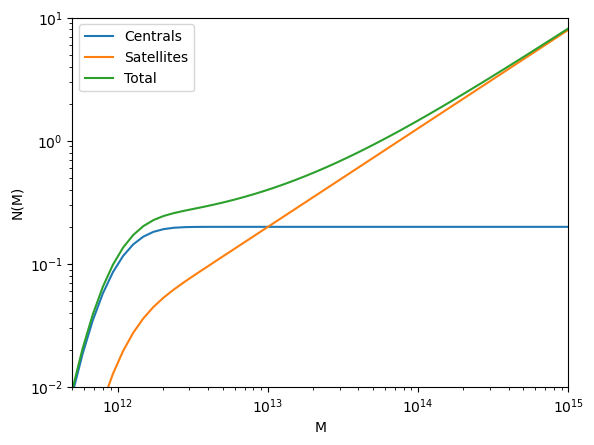

In [5]:
# First, let's recreate Figure 1 from Zacharegkas+22:
m_arr = np.geomspace(5e11, 1e15)
pg = HaloProfileHOD_DES(log10Mmin_0=12, log10M1_0=13, fc_0=0.2, alpha_0=0.8, siglogM_0=0.25, mass_def='200c', concentration=cM)
plt.loglog(m_arr, pg._Nc(m_arr, 1), label='Centrals')
plt.loglog(m_arr, pg._Ns(m_arr, 1), label='Satellites')
plt.loglog(m_arr, pg._Nc(m_arr, 1) + pg._Ns(m_arr, 1), label='Total')
plt.ylim(1e-2, 1e1)
plt.xlim(5e11, 1e15)
plt.xlabel('M')
plt.ylabel('N(M)')
plt.legend()

Comparing the above figure to the DES result, they are completely identical. So my formulae for N_c and N_s are in agreement with DES.

In [6]:
# Now let's set up the HOD for the Lens 1 x Source 3 bin using the parameters from Table D1 in Zacharegkas+22
log10Mmin = 11.97
log10M1 = 13.51
sigma = 0.26
alpha = 1.88
fc = 0.12
a = 1.09
pg = HaloProfileHOD_DES(mass_def=hmd_200c, concentration=cM, log10Mmin_0=log10Mmin, log10M1_0=log10M1, alpha_0=alpha, siglogM_0=sigma, fc_0=fc, aratio_0=a)

In [7]:
# Now let's check whether the derived parameters match the DES paper:

def integrate_over_redshift(func, z_arr, nz_arr):
    vals = [func(cosmo, (1/(1+z)), hmc=hmc) for z in z_arr]
    return np.average(vals, weights=nz_arr)

z_lens_use = nz_lens['Z_MID']
nz_lens_use = nz_lens['BIN1']

delta_z = 0.0 # The nuisance parameter for the shift in N(z).
print(f'INTEGRATING OVER n(z):')
print(f'n_g = {integrate_over_redshift(pg.get_normalization, delta_z+z_lens_use[5:], nz_lens_use[5:])/(cosmo['h']**3):.5f} [h/Mpc]^3')
print(f'alpha_sat = {integrate_over_redshift(pg.get_alpha_sat, delta_z+z_lens_use[5:], nz_lens_use[5:]):.4f}')
print(f'b_g = {integrate_over_redshift(pg.get_linear_bias, delta_z+z_lens_use[5:], nz_lens_use[5:]):.4f}')
print(f'logM_h (200m) = {np.log10(integrate_over_redshift(pg.get_avg_halo_mass_200m, delta_z+z_lens_use[5:], nz_lens_use[5:])):.4f} [Msun]')

print('\nDES RESULTS FROM TABLE D1:')
print('n_g = 0.00098 [h/Mpc]^3 (this is not listed in the table, but is quoted on page 9)')
print('alpha_sat = 0.16')
print('b_g = 1.73')
print('log10M_h = 13.66')

INTEGRATING OVER n(z):
n_g = 0.00103 [h/Mpc]^3
alpha_sat = 0.1496
b_g = 1.4760
logM_h (200m) = 13.7157 [Msun]

DES RESULTS FROM TABLE D1:
n_g = 0.00098 [h/Mpc]^3 (this is not listed in the table, but is quoted on page 9)
alpha_sat = 0.16
b_g = 1.73
log10M_h = 13.66


In [8]:
# We can also check what happens if we fix the redshift at the mean for Lens Bin 1.
z_use = np.average(nz_lens['Z_MID'], weights=nz_lens['BIN1'])
print(f'SET z={z_use:.4f}:')
print(f'n_g = {pg.get_normalization(cosmo, (1/(1+z_use)), hmc=hmc)/(cosmo['h']**3):.5f} [h/Mpc]^3')
print(f'alpha_sat = {pg.get_alpha_sat(cosmo, (1/(1+z_use)), hmc=hmc):.4f}')
print(f'b_g = {pg.get_linear_bias(cosmo, (1/(1+z_use)), hmc=hmc):.4f}')
print(f'logM_h (200m) = {np.log10(pg.get_avg_halo_mass_200m(cosmo, (1/(1+z_use)), hmc=hmc)):.4f} [Msun]')

SET z=0.2730:
n_g = 0.00103 [h/Mpc]^3
alpha_sat = 0.1493
b_g = 1.4748
logM_h (200m) = 13.7091 [Msun]


The above results are different from the DES values, and in particular my value for b_g is significantly off.

# Now let's look at the actual correlation functions:

In [9]:
# Define the tracers
lens_bin = 1
source_bin = 3

theta = np.geomspace(2e-1, 2e2) #[arcmin]

# Again using the HOD parameters for this bin combo in Table D1 of Zacharegkas+22
log10Mmin = 11.97
log10M1 = 13.51
sigma = 0.26
alpha = 1.88
fc = 0.12
a = 1.09

t_g = ccl.NumberCountsTracer(
        cosmo,
        dndz=(nz_lens['Z_MID'], nz_lens[f'BIN{lens_bin}']),
        # The bias is taken into account by the HOD
        bias=(nz_lens['Z_MID'], np.ones_like(nz_lens[f'BIN{lens_bin}']) * 1), 
        # No mag bias here because I am only interested in the HOD terms
        mag_bias=None,
        has_rsd=False,
    )
t_M = ccl.WeakLensingTracer(
    cosmo, dndz=(nz_source['Z_MID'], nz_source[f'BIN{source_bin}'])
    )

In [10]:
# We want to match Figure 4 from Zacharegkas+22, so we need to look at the c1h, s1h, c2h, and s2h terms separately. 
# Create central and satellite HOD objects:
pg_cen = HaloProfileHOD_DES(mass_def=hmd_200c, concentration=cM,
                            log10Mmin_0=log10Mmin,
                            log10M1_0=log10M1,
                            alpha_0=alpha,
                            siglogM_0=sigma,
                            fc_0=fc,
                            aratio_0=a,
                            cen_on=True, sat_on=False,
                            )
pg_sat = HaloProfileHOD_DES(mass_def=hmd_200c, concentration=cM,
                            log10Mmin_0=log10Mmin,
                            log10M1_0=log10M1,
                            alpha_0=alpha,
                            siglogM_0=sigma,
                            fc_0=fc,
                            aratio_0=a,
                            cen_on=False, sat_on=True,
                            )

In [11]:
# Generate galaxy-matter power spectra using the nonlinear matter power spectrum
pk_gMf_c1h = ccl.halos.halomod_Pk2D(cosmo, hmc, pg_cen, prof2=pM, p_of_k_a=cosmo.get_nonlin_power(), lk_arr=np.log(k_arr), a_arr=a_arr, get_1h=True, get_2h=False)   
pk_gMf_s1h = ccl.halos.halomod_Pk2D(cosmo, hmc, pg_sat, prof2=pM, p_of_k_a=cosmo.get_nonlin_power(), lk_arr=np.log(k_arr), a_arr=a_arr, get_1h=True, get_2h=False)
pk_gMf_c2h = ccl.halos.halomod_Pk2D(cosmo, hmc, pg_cen, prof2=pM, p_of_k_a=cosmo.get_nonlin_power(), lk_arr=np.log(k_arr), a_arr=a_arr, get_1h=False, get_2h=True)   
pk_gMf_s2h = ccl.halos.halomod_Pk2D(cosmo, hmc, pg_sat, prof2=pM, p_of_k_a=cosmo.get_nonlin_power(), lk_arr=np.log(k_arr), a_arr=a_arr, get_1h=False, get_2h=True)    

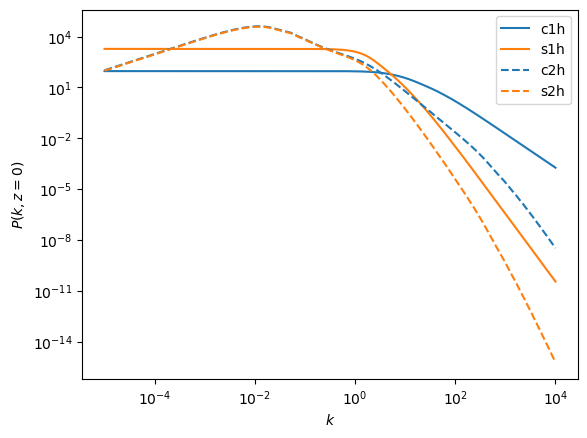

In [12]:
plt.loglog(k_arr, pk_gMf_c1h(k_arr, 1), label='c1h', color='C0', ls='-')
plt.loglog(k_arr, pk_gMf_s1h(k_arr, 1), label='s1h', color='C1', ls='-')
plt.loglog(k_arr, pk_gMf_c2h(k_arr, 1), label='c2h', color='C0', ls='--')
plt.loglog(k_arr, pk_gMf_s2h(k_arr, 1), label='s2h', color='C1', ls='--')
plt.xlabel('$k$')
plt.ylabel('$P(k, z=0)$')
plt.legend()

In [13]:
# Project to 2d and then Hankel transform
cl_gM_c1h = ccl.angular_cl(cosmo, t_g, t_M, l_arr, p_of_k_a=pk_gMf_c1h)
cl_gM_s1h = ccl.angular_cl(cosmo, t_g, t_M, l_arr, p_of_k_a=pk_gMf_s1h)
cl_gM_c2h = ccl.angular_cl(cosmo, t_g, t_M, l_arr, p_of_k_a=pk_gMf_c2h)
cl_gM_s2h = ccl.angular_cl(cosmo, t_g, t_M, l_arr, p_of_k_a=pk_gMf_s2h)
c1h = ccl.correlation(cosmo, ell=l_arr, C_ell=cl_gM_c1h, theta=theta / 60, type="NG", method="FFTLog")
s1h = ccl.correlation(cosmo, ell=l_arr, C_ell=cl_gM_s1h, theta=theta / 60, type="NG", method="FFTLog")
c2h = ccl.correlation(cosmo, ell=l_arr, C_ell=cl_gM_c2h, theta=theta / 60, type="NG", method="FFTLog")
s2h = ccl.correlation(cosmo, ell=l_arr, C_ell=cl_gM_s2h, theta=theta / 60, type="NG", method="FFTLog")

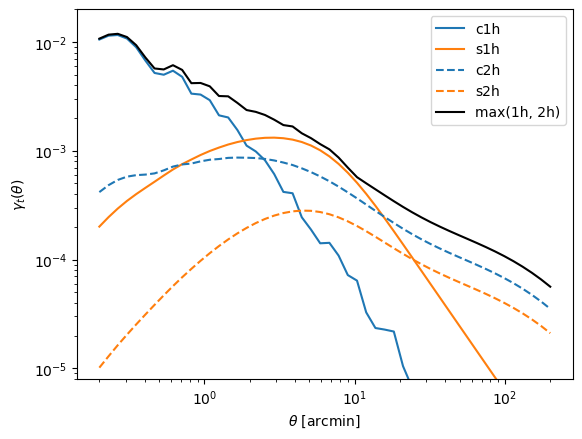

In [14]:
plt.loglog(theta, c1h, label='c1h', color='C0', ls='-')
plt.loglog(theta, s1h, label='s1h', color='C1', ls='-')
plt.loglog(theta, c2h, label='c2h', color='C0', ls='--')
plt.loglog(theta, s2h, label='s2h', color='C1', ls='--')
plt.loglog(theta, np.maximum(c1h + s1h, c2h + s2h), label='max(1h, 2h)', color='black')
plt.ylim(8e-6, 2e-2)
plt.xlabel('$\\theta$ [arcmin]')
plt.ylabel('$\\gamma_t(\\theta)$')
plt.legend()

Note that the c1h term has numerical instability due to the way CCL computes the Hankel transform. This can be easily fixed by using a different integration package, but it makes the integration much slower. In addition, since in this case the c1h term seems to mostly agree with the DES results, I will leave it as is.

If we overlay the above plot onto Figure 4 from Zacharegkas+22, it's clear that the satellite terms are way off. My satellite terms are lower at all scales. Another difference that's visually obvious, even without overlaying the images, is that in my model, the s1h term goes below the c2h term at small scales. But this does not happen in the DES model. 

# Testing the u_sat profile:

Since the difference mainly seems to be in the satellite term, could the discrepancy be coming from my implementation of the satellite distribution term u_sat?

In [15]:
# This is the same implementation as I used in the HOD model.
# But I'm moving it to a separate class to take advantage of the automatic FFT in the CCL HaloProfileMatter class.

class HaloProfileNFW_sat(ccl.halos.HaloProfileMatter):
    __repr_attrs__ = __eq_attrs__ = (
        "fourier_analytic", "projected_analytic", "cumul2d_analytic",
        "truncated", "mass_def", "concentration", "precision_fftlog",)

    def __init__(self, *, mass_def, concentration, aratio,
                 fourier_analytic=True,
                 projected_analytic=False,
                 cumul2d_analytic=False,
                 truncated=True):
        self.aratio=aratio
        self.truncated = truncated
        self.fourier_analytic = fourier_analytic
        self.projected_analytic = projected_analytic
        self.cumul2d_analytic = cumul2d_analytic
        if fourier_analytic:
            self._fourier = self._fourier_analytic
        if projected_analytic:
            if truncated:
                raise ValueError("Analytic projected profile not supported "
                                 "for truncated NFW. Set `truncated` or "
                                 "`projected_analytic` to `False`.")
            self._projected = self._projected_analytic
        if cumul2d_analytic:
            if truncated:
                raise ValueError("Analytic cumuative 2d profile not supported "
                                 "for truncated NFW. Set `truncated` or "
                                 "`cumul2d_analytic` to `False`.")
            self._cumul2d = self._cumul2d_analytic
        self._omln2 = 1 - np.log(2)
        super().__init__(mass_def=mass_def, concentration=concentration)
        self.update_precision_fftlog(padding_hi_fftlog=1E2,
                                     padding_lo_fftlog=1E-2,
                                     n_per_decade=1000,
                                     plaw_fourier=-2.)

    def _norm(self, M, Rs, c):
        # NFW normalization from mass, radius and concentration
        return 1 / (4 * np.pi * Rs**3 * (np.log(1+c) - c/(1+c)))

    def _real(self, cosmo, r, M, a):
        r_use = np.atleast_1d(r)
        M_use = np.atleast_1d(M)

        # Comoving virial radius
        R_M = self.mass_def.get_radius(cosmo, M_use, a) / a
        c_M = self.aratio * self.concentration(cosmo, M_use, a)
        R_s = R_M / c_M

        x = r_use[None, :] / R_s[:, None]
        prof = 1./(x * (1 + x)**2)
        if self.truncated:
            prof[r_use[None, :] > R_M[:, None]] = 0

        norm = self._norm(M_use, R_s, c_M)
        prof = prof[:, :] * norm[:, None]

        if np.ndim(r) == 0:
            prof = np.squeeze(prof, axis=-1)
        if np.ndim(M) == 0:
            prof = np.squeeze(prof, axis=0)
        return prof

    def _fourier_analytic(self, cosmo, k, M, a):
        M_use = np.atleast_1d(M)
        k_use = np.atleast_1d(k)

        # Comoving virial radius
        R_M = self.mass_def.get_radius(cosmo, M_use, a) / a
        c_M = self.aratio * self.concentration(cosmo, M_use, a)
        R_s = R_M / c_M

        x = k_use[None, :] * R_s[:, None]
        Si2, Ci2 = sici(x)
        P1 = 1 / (np.log(1 + c_M) - c_M / (1 + c_M))
        if self.truncated:
            Si1, Ci1 = sici((1 + c_M[:, None]) * x)
            P2 = np.sin(x) * (Si1 - Si2) + np.cos(x) * (Ci1 - Ci2)
            P3 = np.sin(c_M[:, None] * x) / ((1 + c_M[:, None]) * x)
            prof = P1[:, None] * (P2 - P3)
        else:
            P2 = np.sin(x) * (0.5 * np.pi - Si2) - np.cos(x) * Ci2
            prof = P1[:, None] * P2

        if np.ndim(k) == 0:
            prof = np.squeeze(prof, axis=-1)
        if np.ndim(M) == 0:
            prof = np.squeeze(prof, axis=0)
        return prof

In [16]:
pnfw = HaloProfileNFW_sat(mass_def=hmd_200c, concentration=cM, fourier_analytic=False, truncated=True, aratio=1)
pnfw_a = HaloProfileNFW_sat(mass_def=hmd_200c, concentration=cM, fourier_analytic=False, truncated=True, aratio=0.7)
pnfw_ana = HaloProfileNFW_sat(mass_def=hmd_200c, concentration=cM, fourier_analytic=True, truncated=True, aratio=1)
pnfw_a_ana = HaloProfileNFW_sat(mass_def=hmd_200c, concentration=cM, fourier_analytic=True, truncated=True, aratio=0.7)

Text(0, 0.5, '$\\rho_{sat}(r)$')

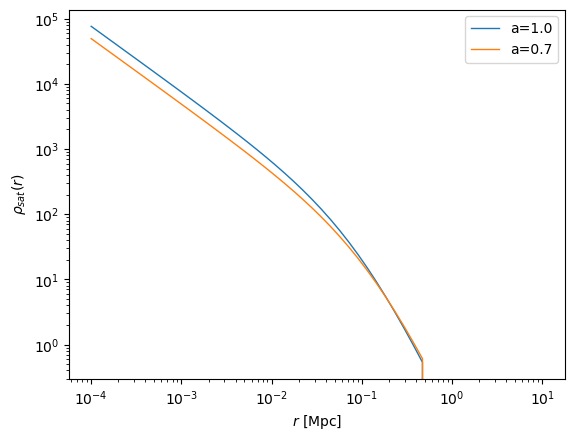

In [17]:
r_arr = np.geomspace(1e-4, 1e1)
plt.loglog(r_arr, pnfw.real(cosmo, r=r_arr, M=1e13, a=0.8), color='C0', lw=1, label='a=1.0')
plt.loglog(r_arr, pnfw_a.real(cosmo, r=r_arr, M=1e13, a=0.8), color='C1', lw=1, label='a=0.7')
plt.legend()
plt.xlabel('$r$ [Mpc]')
plt.ylabel('$\\rho_{sat}(r)$')

Text(0, 0.5, '$u_{sat}(k)$')

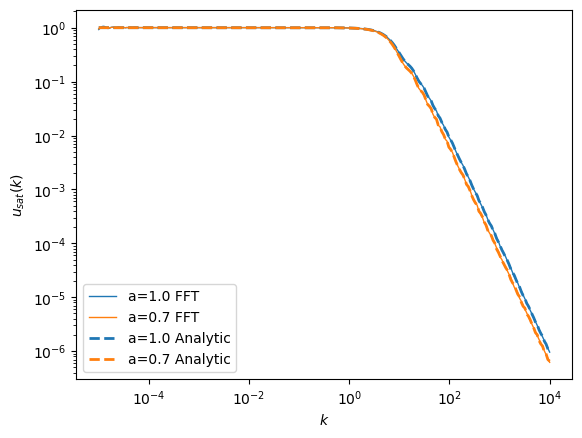

In [18]:
plt.loglog(k_arr, pnfw.fourier(cosmo, k=k_arr, M=1e13, a=0.8), color='C0', lw=1, label='a=1.0 FFT')
plt.loglog(k_arr, pnfw_a.fourier(cosmo, k=k_arr, M=1e13, a=0.8), color='C1', lw=1, label='a=0.7 FFT')
plt.loglog(k_arr, pnfw_ana.fourier(cosmo, k=k_arr, M=1e13, a=0.8), color='C0', ls='--', lw=2, label='a=1.0 Analytic')
plt.loglog(k_arr, pnfw_a_ana.fourier(cosmo, k=k_arr, M=1e13, a=0.8), color='C1', ls='--', lw=2, label='a=0.7 Analytic')
plt.legend()
plt.xlabel('$k$')
plt.ylabel('$u_{sat}(k)$')

In the above plot we see that the analytic and FFT methods give the same results when computing $u_{sat}(k)$. This validates the analytic formula I implement.